# OpenAQ Data Preprocessing — all_stations_crawled.csv

Pipeline:
1. Load & explore raw hourly data
2. Parse datetime, clean outliers
3. Fill hourly gaps (reindex + interpolate)
4. Aggregate to daily (mean / std / count)
5. Add time features
6. Train / validation / test split (70 / 15 / 15, chronological)
7. Save outputs to `data/interim/openaq/`

## 1. Imports & Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Paths
PROJECT_ROOT = Path("D:/Bussiness_plan/Multimodal_PM25")
INPUT_CSV    = PROJECT_ROOT / "data/raw/DataAOD/Hanoi/all_stations_crawled.csv"
OUTPUT_DIR   = PROJECT_ROOT / "data/interim/openaq"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Preprocessing settings
TRAIN_FRAC      = 0.70
VAL_FRAC        = 0.15
# TEST_FRAC     = 0.15  (remainder)

PM25_MIN, PM25_MAX = 0, 500   # µg/m³ valid range
CO_MAX             = 100_000  # µg/m³
NO2_MAX            = 1_000
O3_MAX             = 1_000
SO2_MAX            = 2_000

INTERP_HOURLY_LIMIT  = 6   # max consecutive missing hours to interpolate
INTERP_DAILY_LIMIT   = 3   # max consecutive missing days to interpolate

PARAM_COLS = [
    "CO mass µg/m³",
    "NO₂ mass µg/m³",
    "O₃ mass µg/m³",
    "PM2.5 µg/m³",
    "SO₂ mass µg/m³",
]

print(f"Input : {INPUT_CSV}")
print(f"Output: {OUTPUT_DIR}")


Input : D:\Bussiness_plan\Multimodal_PM25\data\raw\DataAOD\Hanoi\all_stations_crawled.csv
Output: D:\Bussiness_plan\Multimodal_PM25\data\interim\openaq


## 2. Load & Explore

In [2]:
df_raw = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
df_raw["datetime_utc"] = pd.to_datetime(df_raw["datetime_utc"], utc=True, errors="coerce")

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Date range: {df_raw['datetime_utc'].min()}  →  {df_raw['datetime_utc'].max()}")
print(f"Stations ({df_raw['location_id'].nunique()}):") 
display(df_raw.groupby("location_id").agg(
    name  =("location_name","first"),
    rows  =("datetime_utc","count"),
    start =("datetime_utc","min"),
    end   =("datetime_utc","max"),
))


Shape: (53088, 10)
Columns: ['datetime_utc', 'location_id', 'location_name', 'latitude', 'longitude', 'CO mass µg/m³', 'NO₂ mass µg/m³', 'O₃ mass µg/m³', 'PM2.5 µg/m³', 'SO₂ mass µg/m³']
Date range: 2024-01-29 17:00:00+00:00  →  2026-05-15 00:00:00+00:00
Stations (6):


,name,rows,start,end
location_id,,,,
2161292,"Số 46, phố Lưu Quang Vũ",16654,2024-01-29 17:00:00+00:00,2026-05-15 00:00:00+00:00
2161306,Minh Khai - Bắc Từ Liêm,9847,2024-01-29 17:00:00+00:00,2026-05-15 00:00:00+00:00
4946811,556 Nguyễn Văn Cừ,7327,2025-07-03 16:00:00+00:00,2026-05-15 00:00:00+00:00
4946812,Công viên Nhân Chính - Khuất Duy Tiến,7434,2025-07-03 16:00:00+00:00,2026-05-15 00:00:00+00:00
4946813,Số 1 đường Giải Phóng - phường Bạch Mai - ĐHBK,7414,2025-07-03 16:00:00+00:00,2026-05-15 00:00:00+00:00
6123215,OceanPark,4412,2025-11-08 07:00:00+00:00,2026-05-15 00:00:00+00:00


In [3]:
# Missing value summary per column per station
miss = (
    df_raw.groupby("location_id")[PARAM_COLS]
    .apply(lambda g: g.isna().mean().rename("missing_rate"))
)
print("Missing-value rates by station:")
display(miss.round(3))


Missing-value rates by station:


missing_rate,CO mass µg/m³,NO₂ mass µg/m³,O₃ mass µg/m³,PM2.5 µg/m³,SO₂ mass µg/m³
location_id,,,,,
2161292,0.109,0.336,0.359,0.039,0.647
2161306,0.313,0.743,0.187,0.310,0.486
4946811,0.533,0.504,0.123,0.021,0.298
4946812,0.019,0.132,0.032,0.004,0.010
4946813,0.649,0.022,0.043,0.046,0.116
6123215,1.000,1.000,1.000,0.000,1.000


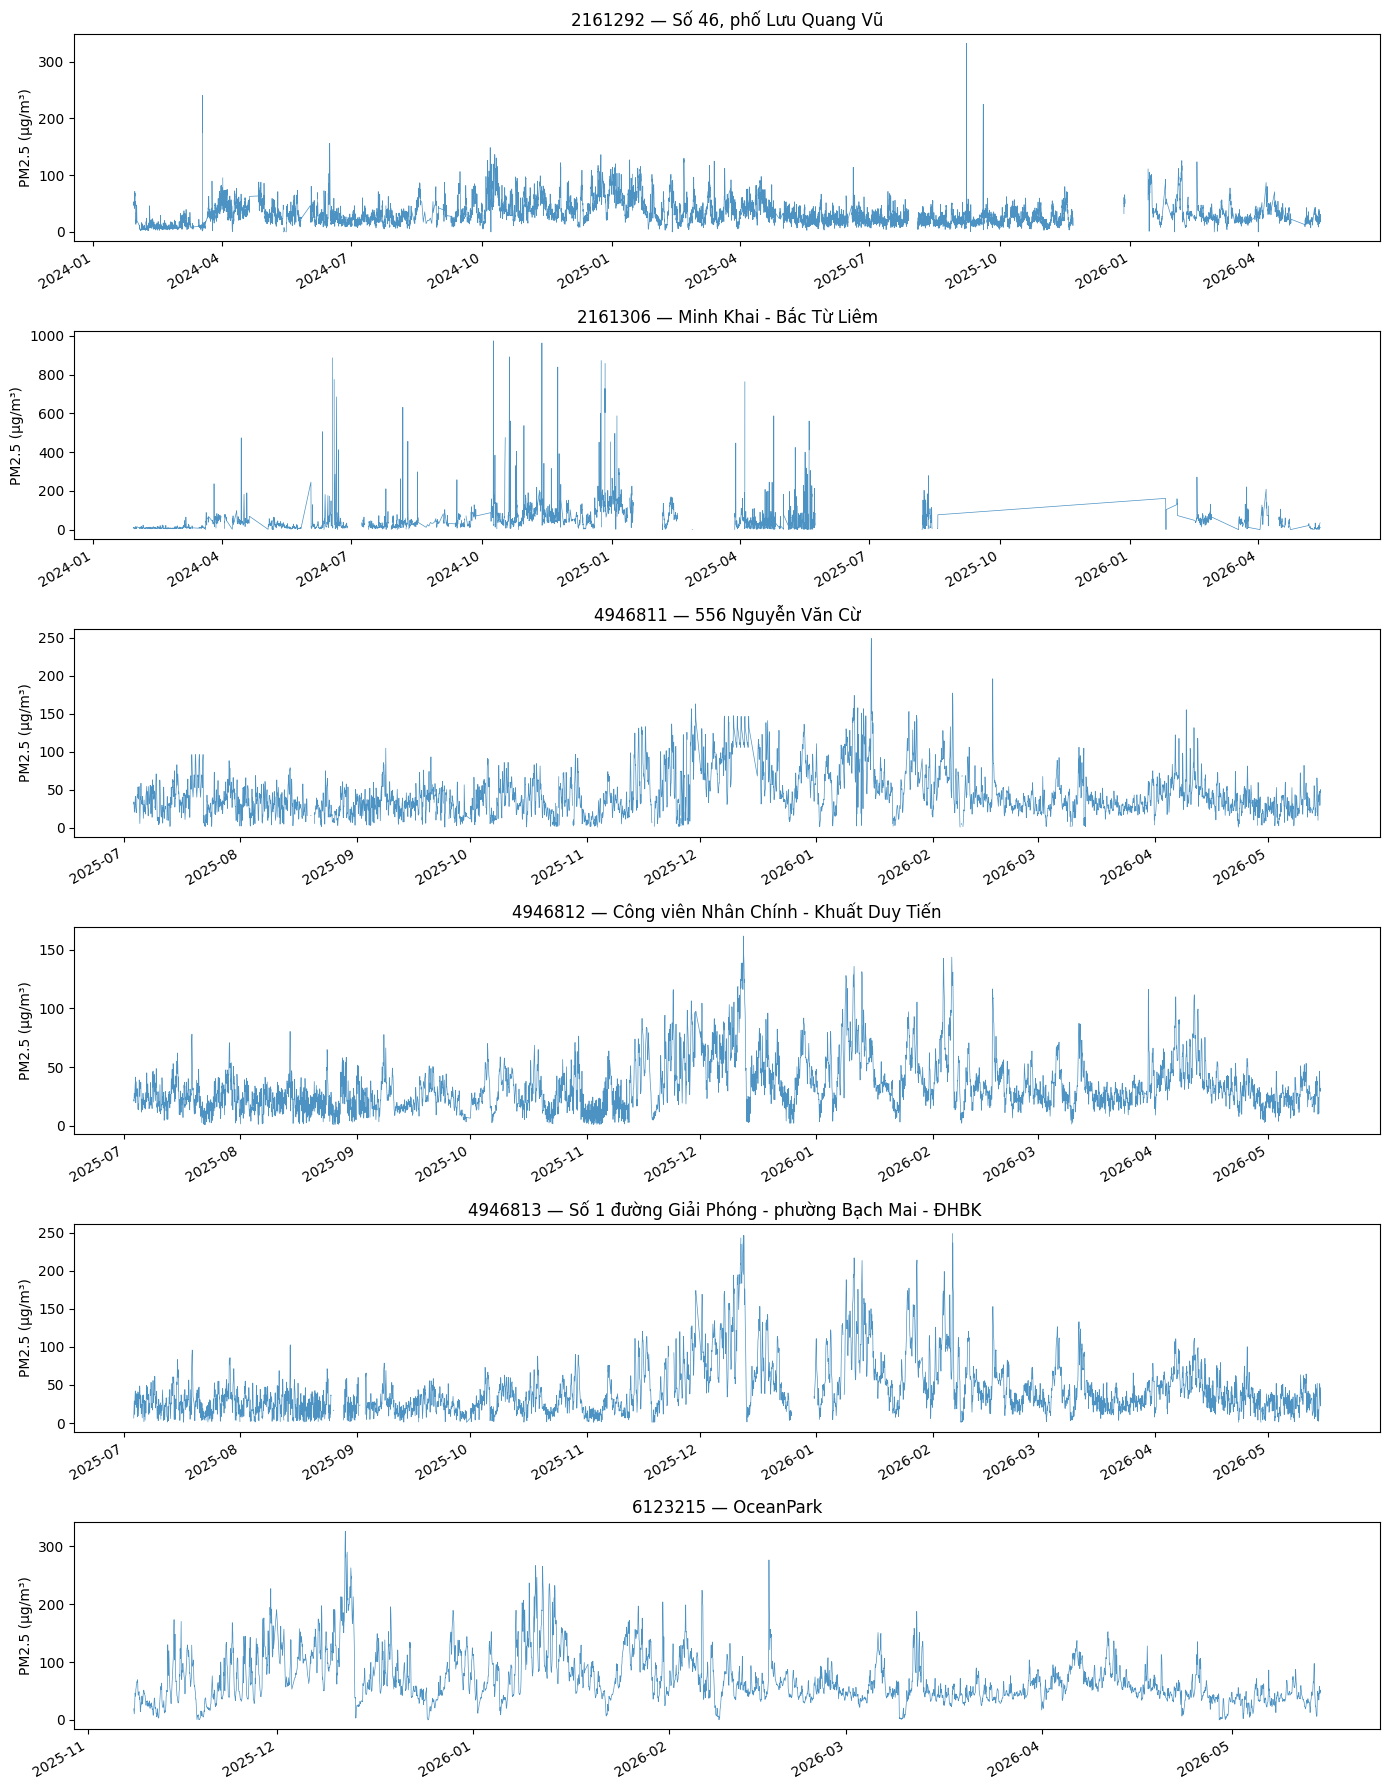

In [4]:
# Quick PM2.5 time-series plot per station
fig, axes = plt.subplots(
    df_raw["location_id"].nunique(), 1,
    figsize=(14, 3 * df_raw["location_id"].nunique()),
    sharex=False,
)
if df_raw["location_id"].nunique() == 1:
    axes = [axes]

for ax, (loc_id, grp) in zip(axes, df_raw.groupby("location_id")):
    grp_sorted = grp.sort_values("datetime_utc")
    ax.plot(grp_sorted["datetime_utc"], grp_sorted["PM2.5 µg/m³"], lw=0.5, alpha=0.8)
    ax.set_title(f"{loc_id} — {grp['location_name'].iloc[0]}")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pm25_raw_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Clean Outliers

In [5]:
df = df_raw.copy()

# Remove rows with unparseable datetime
n_bad_dt = df["datetime_utc"].isna().sum()
if n_bad_dt: print(f"Dropping {n_bad_dt} rows with bad datetime")
df = df.dropna(subset=["datetime_utc"]).reset_index(drop=True)

# Clip each parameter to valid range (keep NaN as NaN)
BOUNDS = {
    "PM2.5 µg/m³":   (PM25_MIN, PM25_MAX),
    "CO mass µg/m³": (0,        CO_MAX),
    "NO₂ mass µg/m³":(0,        NO2_MAX),
    "O₃ mass µg/m³": (0,        O3_MAX),
    "SO₂ mass µg/m³":(0,        SO2_MAX),
}
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    mask = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    if mask.any():
        print(f"  {col}: setting {mask.sum()} out-of-range values to NaN")
    df.loc[mask, col] = np.nan

print(f"Cleaned shape: {df.shape}")


  PM2.5 µg/m³: setting 22 out-of-range values to NaN
Cleaned shape: (53088, 10)


## 4. Fill Hourly Gaps (Reindex + Interpolate)

In [6]:
parts = []

for loc_id, grp in df.groupby("location_id", sort=False):
    grp = grp.sort_values("datetime_utc").set_index("datetime_utc")

    # Build complete hourly index
    full_idx = pd.date_range(grp.index.min(), grp.index.max(), freq="h", tz="UTC")
    grp = grp.reindex(full_idx)
    grp.index.name = "datetime_utc"

    # Forward-fill metadata columns
    for col in ["location_id", "location_name", "latitude", "longitude"]:
        if col in grp.columns:
            grp[col] = grp[col].ffill().bfill()

    # Track which PM2.5 values were originally missing
    grp["pm25_was_missing"] = grp["PM2.5 µg/m³"].isna().astype("int8")

    # Interpolate each parameter over short gaps
    for col in PARAM_COLS:
        if col in grp.columns:
            grp[col] = grp[col].interpolate(
                method="time",
                limit=INTERP_HOURLY_LIMIT,
                limit_direction="forward",
            )

    parts.append(grp.reset_index())

df_hourly = pd.concat(parts, ignore_index=True)
df_hourly["location_id"] = df_hourly["location_id"].astype("int64")

print(f"Hourly shape after reindex+interpolate: {df_hourly.shape}")
display(df_hourly.groupby("location_id").agg(
    rows     =("datetime_utc","count"),
    pm25_ok  =(("PM2.5 µg/m³"), lambda x: x.notna().sum()),
    pm25_miss=(("pm25_was_missing"), "sum"),
))


Hourly shape after reindex+interpolate: (67357, 11)


,rows,pm25_ok,pm25_miss
location_id,,,
2161292,20072,16810,4069
2161306,20072,8696,13302
4946811,7569,7405,398
4946812,7569,7509,165
4946813,7569,7273,493
6123215,4506,4494,94


In [7]:
# Save hourly cleaned file
out_hourly = OUTPUT_DIR / "all_stations_hourly.csv"
df_hourly.to_csv(out_hourly, index=False, encoding="utf-8-sig")
print(f"Saved: {out_hourly.name}  shape={df_hourly.shape}")


Saved: all_stations_hourly.csv  shape=(67357, 11)


## 5. Aggregate to Daily

In [8]:
df_hourly["date"] = df_hourly["datetime_utc"].dt.normalize()

agg_funcs = {
    "PM2.5 µg/m³":    ["mean","std","min","max","count"],
    "CO mass µg/m³":  ["mean","std"],
    "NO₂ mass µg/m³": ["mean","std"],
    "O₃ mass µg/m³":  ["mean","std"],
    "SO₂ mass µg/m³": ["mean","std"],
    "pm25_was_missing":["sum"],
}

df_daily = (
    df_hourly
    .groupby(["location_id","location_name","latitude","longitude","date"])
    .agg(agg_funcs)
    .reset_index()
)

# Flatten MultiIndex columns
df_daily.columns = [
    "_".join(filter(None, map(str, col))).strip("_")
    if isinstance(col, tuple) else col
    for col in df_daily.columns
]

# Rename for clarity
rename_map = {
    "PM2.5 µg/m³_mean":    "pm25_mean",
    "PM2.5 µg/m³_std":     "pm25_std",
    "PM2.5 µg/m³_min":     "pm25_min",
    "PM2.5 µg/m³_max":     "pm25_max",
    "PM2.5 µg/m³_count":   "pm25_hourly_count",
    "CO mass µg/m³_mean":  "co_mean",
    "CO mass µg/m³_std":   "co_std",
    "NO₂ mass µg/m³_mean": "no2_mean",
    "NO₂ mass µg/m³_std":  "no2_std",
    "O₃ mass µg/m³_mean":  "o3_mean",
    "O₃ mass µg/m³_std":   "o3_std",
    "SO₂ mass µg/m³_mean": "so2_mean",
    "SO₂ mass µg/m³_std":  "so2_std",
    "pm25_was_missing_sum":"pm25_missing_hours",
}
df_daily = df_daily.rename(columns=rename_map)
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_daily = df_daily.sort_values(["location_id","date"]).reset_index(drop=True)

print(f"Daily shape: {df_daily.shape}")
display(df_daily.head())


Daily shape: (2816, 19)


,location_id,location_name,latitude,longitude,date,pm25_mean,pm25_std,pm25_min,pm25_max,pm25_hourly_count,co_mean,co_std,no2_mean,no2_std,o3_mean,o3_std,so2_mean,so2_std,pm25_missing_hours
0,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-29 00:00:00+00:00,49.964286,2.430993,45.920000,53.020000,7,602.028571,125.678329,NaN,NaN,26.598571,0.111569,1.742857,0.023604,0
1,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-30 00:00:00+00:00,55.806250,10.596282,36.860000,71.400000,24,1100.100000,342.426232,NaN,NaN,26.568333,0.082497,2.135833,0.205488,0
2,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-31 00:00:00+00:00,30.300000,10.179224,13.380000,47.460000,24,1525.387500,746.748536,NaN,NaN,26.557917,0.100951,2.704583,0.452903,0
3,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-02-01 00:00:00+00:00,19.106829,0.407932,18.561707,19.651951,6,1148.401220,34.208787,NaN,NaN,26.563171,0.033766,3.021341,0.026009,24
4,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-02-02 00:00:00+00:00,8.741250,2.056338,6.050000,12.010000,8,413.162500,102.273791,NaN,NaN,26.858750,1.012514,2.485000,0.069076,16


## 6. Fill Daily Gaps & Time Features

In [9]:
daily_parts = []

for loc_id, grp in df_daily.groupby("location_id", sort=False):
    grp = grp.sort_values("date").set_index("date")

    # Reindex to full daily calendar
    full_days = pd.date_range(grp.index.min(), grp.index.max(), freq="D")
    grp = grp.reindex(full_days)
    grp.index.name = "date"

    for col in ["location_id","location_name","latitude","longitude"]:
        if col in grp.columns:
            grp[col] = grp[col].ffill().bfill()

    grp["pm25_was_interpolated"] = grp["pm25_mean"].isna().astype("int8")
    grp["pm25_mean"] = grp["pm25_mean"].interpolate(
        method="time", limit=INTERP_DAILY_LIMIT, limit_direction="forward"
    )

    # Interpolate other daily features
    other_num = [c for c in grp.select_dtypes("number").columns
                 if c not in {"pm25_was_interpolated"}]
    grp[other_num] = grp[other_num].interpolate(
        method="time", limit=7, limit_direction="both"
    )

    # Drop remaining rows without pm25
    grp = grp[grp["pm25_mean"].notna()].reset_index()
    daily_parts.append(grp)

df_daily_filled = pd.concat(daily_parts, ignore_index=True)
df_daily_filled["location_id"] = df_daily_filled["location_id"].astype("int64")

# Time features
df_daily_filled["day_of_week"]  = df_daily_filled["date"].dt.dayofweek
df_daily_filled["day_of_year"]  = df_daily_filled["date"].dt.dayofyear
df_daily_filled["month"]        = df_daily_filled["date"].dt.month
df_daily_filled["year"]         = df_daily_filled["date"].dt.year
df_daily_filled["is_weekend"]   = df_daily_filled["day_of_week"].isin([5,6]).astype("int8")
df_daily_filled["season"] = df_daily_filled["month"].map(
    lambda m: "winter" if m in [12,1,2]
              else "spring" if m in [3,4,5]
              else "summer" if m in [6,7,8]
              else "autumn"
)

print(f"Daily filled shape: {df_daily_filled.shape}")
display(df_daily_filled.groupby("location_id").agg(
    name     =("location_name","first"),
    rows     =("date","count"),
    pm25_ok  =("pm25_mean", lambda x: x.notna().sum()),
    pm25_interp=("pm25_was_interpolated","sum"),
    start    =("date","min"),
    end      =("date","max"),
))


Daily filled shape: (2585, 26)


,name,rows,pm25_ok,pm25_interp,start,end
location_id,,,,,,
2161292,"Số 46, phố Lưu Quang Vũ",820,820,72,2024-01-29 00:00:00+00:00,2026-05-15 00:00:00+00:00
2161306,Minh Khai - Bắc Từ Liêm,625,625,205,2024-01-29 00:00:00+00:00,2026-05-15 00:00:00+00:00
4946811,556 Nguyễn Văn Cừ,317,317,1,2025-07-03 00:00:00+00:00,2026-05-15 00:00:00+00:00
4946812,Công viên Nhân Chính - Khuất Duy Tiến,317,317,0,2025-07-03 00:00:00+00:00,2026-05-15 00:00:00+00:00
4946813,Số 1 đường Giải Phóng - phường Bạch Mai - ĐHBK,317,317,6,2025-07-03 00:00:00+00:00,2026-05-15 00:00:00+00:00
6123215,OceanPark,189,189,0,2025-11-08 00:00:00+00:00,2026-05-15 00:00:00+00:00


## 7. Train / Validation / Test Split (Chronological)

In [10]:
# Global calendar cutoffs so all stations share the same split boundaries
all_dates = np.sort(df_daily_filled["date"].dt.normalize().unique())
n = len(all_dates)
train_cutoff = all_dates[int(n * TRAIN_FRAC)]
val_cutoff   = all_dates[int(n * (TRAIN_FRAC + VAL_FRAC))]

print(f"Total unique dates : {n}")
print(f"Train  cutoff      : {train_cutoff.date()} (idx {int(n*TRAIN_FRAC)})")
print(f"Val    cutoff      : {val_cutoff.date()}   (idx {int(n*(TRAIN_FRAC+VAL_FRAC))})")

df_daily_filled["split"] = "test"
df_daily_filled.loc[df_daily_filled["date"] < train_cutoff, "split"] = "train"
df_daily_filled.loc[
    (df_daily_filled["date"] >= train_cutoff) & (df_daily_filled["date"] < val_cutoff),
    "split"
] = "validation"

display(df_daily_filled.groupby(["location_id","split"]).agg(
    rows=("date","count"),
    pm25_mean=("pm25_mean","mean"),
    pm25_max =("pm25_mean","max"),
    start=("date","min"),
    end  =("date","max"),
).round(1))


Total unique dates : 838
Train  cutoff      : 2025-09-06 (idx 586)
Val    cutoff      : 2026-01-10   (idx 712)


rows  pm25_mean  pm25_max                     start  \
location_id split                                                             
2161292     test         126       33.2      92.0 2026-01-10 00:00:00+00:00   
            train        586       33.5      98.7 2024-01-29 00:00:00+00:00   
            validation   108       31.7      75.5 2025-09-06 00:00:00+00:00   
2161306     test         118       46.2     143.9 2026-01-18 00:00:00+00:00   
            train        507       50.1     198.9 2024-01-29 00:00:00+00:00   
4946811     test         126       45.3     137.3 2026-01-10 00:00:00+00:00   
            train         65       33.0      65.2 2025-07-03 00:00:00+00:00   
            validation   126       52.3     136.8 2025-09-06 00:00:00+00:00   
4946812     test         126       37.9      91.2 2026-01-10 00:00:00+00:00   
            train         65       23.2      42.3 2025-07-03 00:00:00+00:00   
            validation   126       37.5     131.9 2025-09-06 00:00:00+00:00   
4946813     test         126       50.2     150.5 2026-01-10 00:00:00+00:00   
            train         65       25.6      49.6 2025-07-03 00:00:00+00:00   
            validation   126       47.6     209.3 2025-09-06 00:00:00+00:00   
6123215     test         126       64.4     165.5 2026-01-10 00:00:00+00:00   
            validation    63       80.5     215.0 2025-11-08 00:00:00+00:00   

                                             end  
location_id split                                 
2161292     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
2161306     test       2026-05-15 00:00:00+00:00  
            train      2025-08-28 00:00:00+00:00  
4946811     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
4946812     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
4946813     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
6123215     test       2026-05-15 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00

## 8. Save Outputs

In [11]:
# All stations combined
out_all = OUTPUT_DIR / "all_stations_daily.csv"
df_daily_filled.to_csv(out_all, index=False, encoding="utf-8-sig")
print(f"Saved: {out_all.name}  shape={df_daily_filled.shape}")

# Split files
for split_name, grp in df_daily_filled.groupby("split", sort=False):
    out = OUTPUT_DIR / f"{split_name}.csv"
    grp.to_csv(out, index=False, encoding="utf-8-sig")
    print(f"  {split_name}.csv  rows={len(grp)}")

# Per-station files
for loc_id, grp in df_daily_filled.groupby("location_id", sort=False):
    out = OUTPUT_DIR / f"station_{loc_id}_daily.csv"
    grp.to_csv(out, index=False, encoding="utf-8-sig")
    print(f"  station_{loc_id}_daily.csv  rows={len(grp)}")

# Hourly (already saved above, just confirm)
print(f"\nAll outputs written to: {OUTPUT_DIR}")


Saved: all_stations_daily.csv  shape=(2585, 27)
  train.csv  rows=1288
  validation.csv  rows=549
  test.csv  rows=748
  station_2161292_daily.csv  rows=820
  station_2161306_daily.csv  rows=625
  station_4946811_daily.csv  rows=317
  station_4946812_daily.csv  rows=317
  station_4946813_daily.csv  rows=317
  station_6123215_daily.csv  rows=189

All outputs written to: D:\Bussiness_plan\Multimodal_PM25\data\interim\openaq


## 9. EDA — Daily PM2.5 by Station & Split

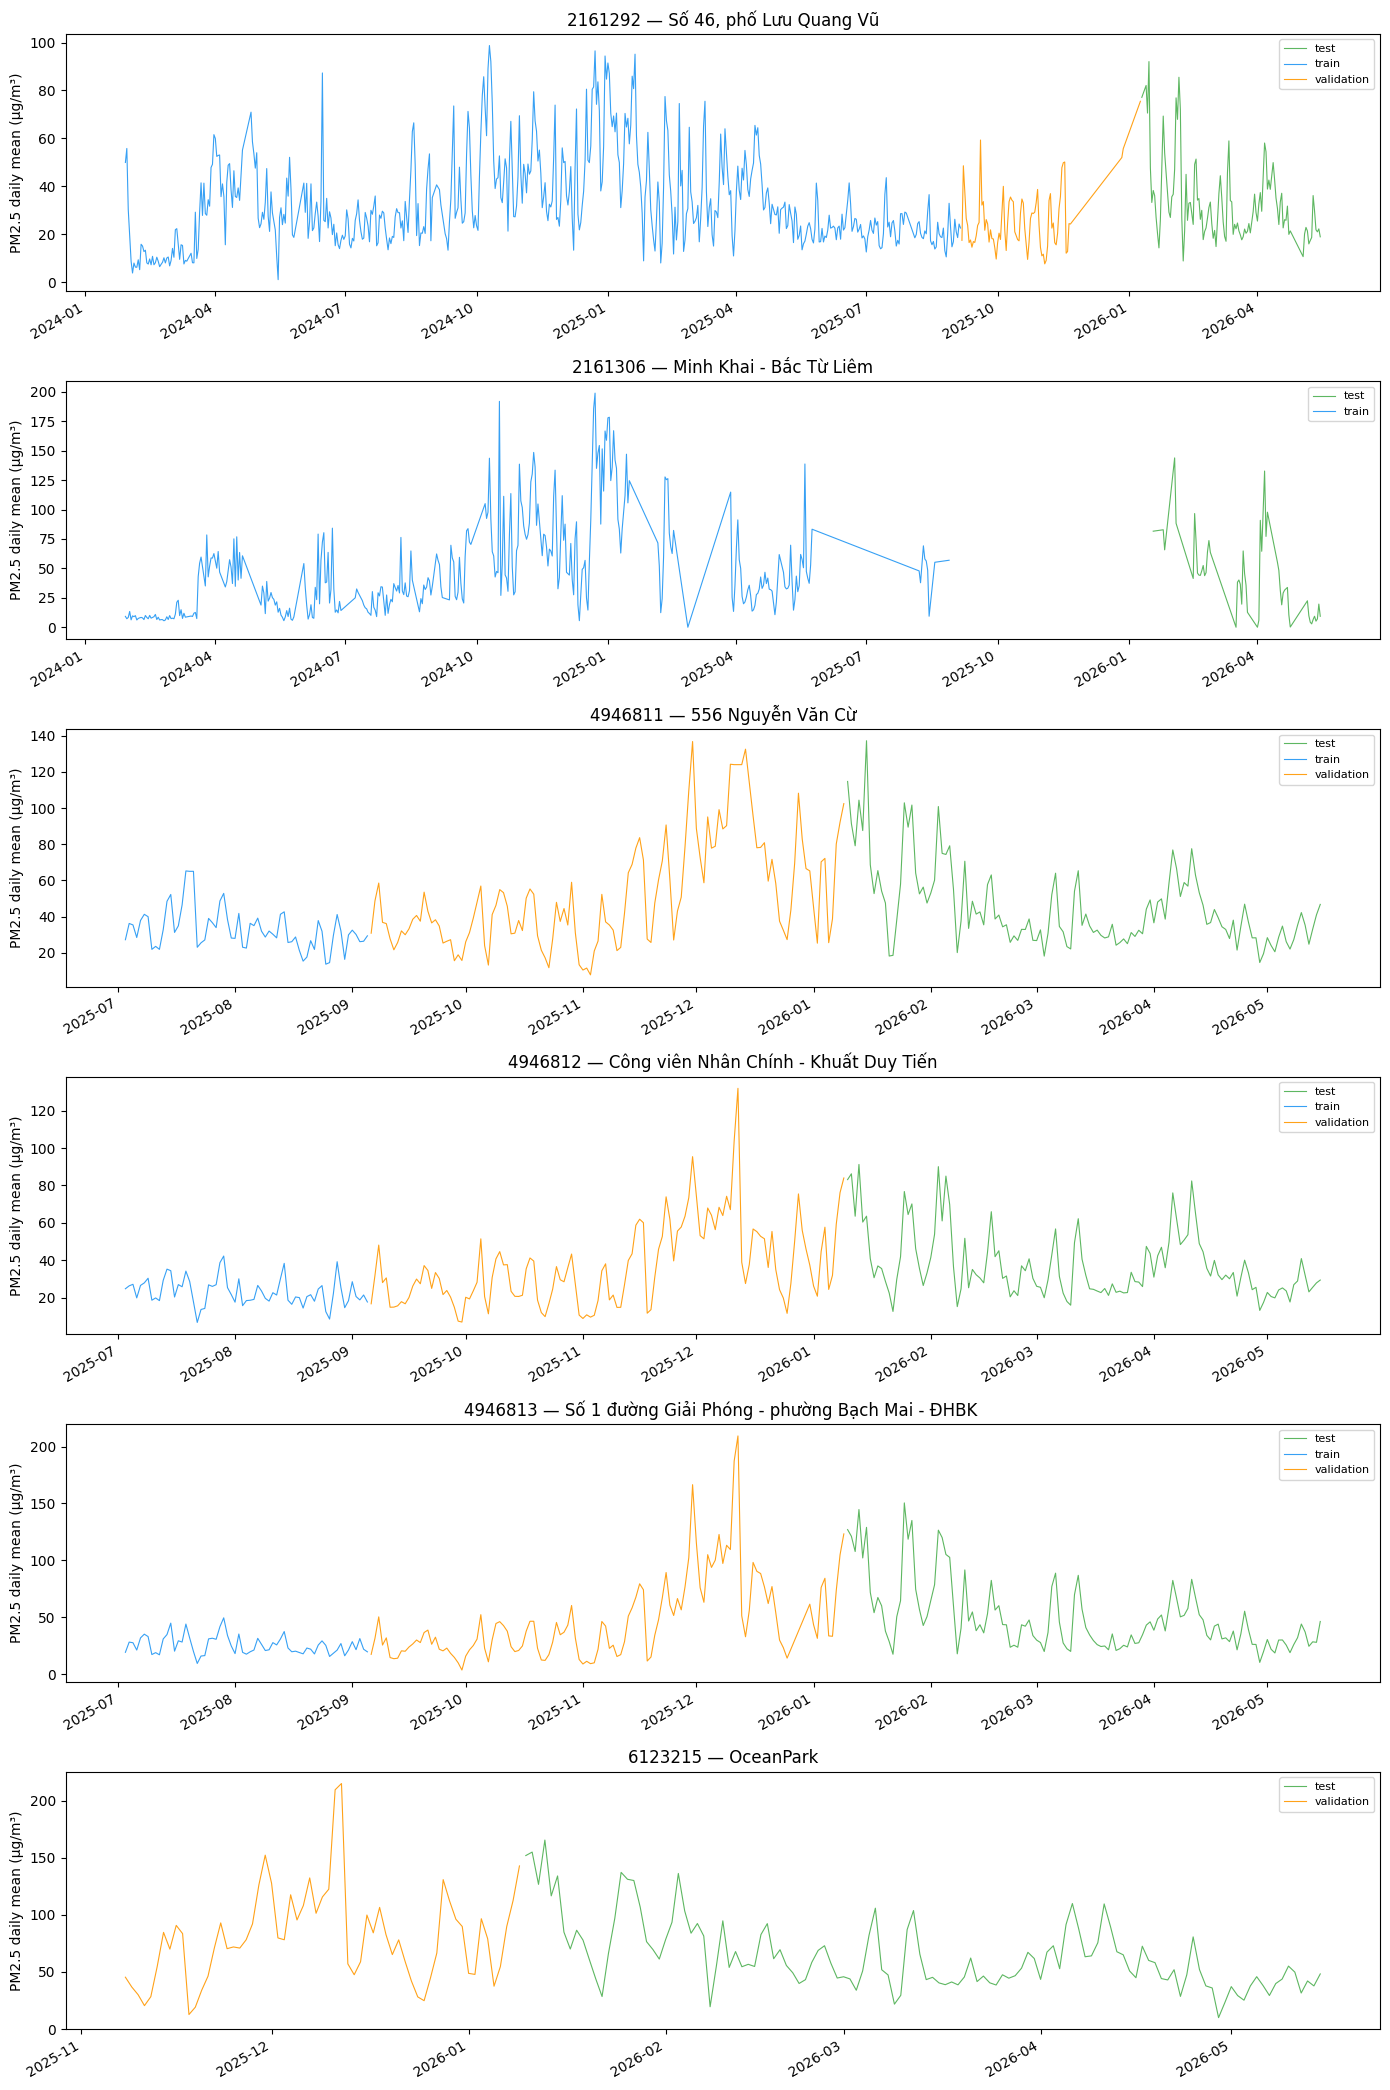

In [12]:
fig, axes = plt.subplots(
    df_daily_filled["location_id"].nunique(), 1,
    figsize=(14, 3.5 * df_daily_filled["location_id"].nunique()),
    sharex=False,
)
if df_daily_filled["location_id"].nunique() == 1:
    axes = [axes]

SPLIT_COLORS = {"train": "#2196F3", "validation": "#FF9800", "test": "#4CAF50"}

for ax, (loc_id, grp) in zip(axes, df_daily_filled.groupby("location_id")):
    grp = grp.sort_values("date")
    for split, sgrp in grp.groupby("split"):
        ax.plot(sgrp["date"], sgrp["pm25_mean"],
                color=SPLIT_COLORS.get(split, "gray"), lw=0.8,
                label=split, alpha=0.9)
    ax.set_title(f"{loc_id} — {grp['location_name'].iloc[0]}")
    ax.set_ylabel("PM2.5 daily mean (µg/m³)")
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pm25_daily_splits.png", dpi=120, bbox_inches="tight")
plt.show()
